# Experiment Explorer

Compare experiments for a given target variable. Selects the best one (by Ridge RMSE) for further analysis.

In [31]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

#Y_COLUMN = "Steam__kWh/T_"
Y_COLUMN = "MBS_SCT_CD"

# Scan all experiments for this target
experiments_dir = Path("experiments") / Y_COLUMN.replace("/", "_")

rows = []
for exp_dir in sorted(experiments_dir.iterdir()):
    results_file = exp_dir / "results.json"
    if not results_file.exists():
        continue
    with open(results_file) as f:
        data = json.load(f)
    params = data["parameters"]
    metrics = data["metrics"]
    rows.append({
        "id": exp_dir.name,
        "path": str(exp_dir),
        "n_iterations": params.get("n_iterations"),
        "gamma": params.get("gamma"),
        "splines": params.get("splines"),
        "ewm": params.get("apply_ewm_filter"),
        "ewm_y": params.get("apply_ewm_filter_y"),
        "best_iter": params.get("best_iteration"),
        "ridge_rmse": metrics["ridge_only"]["rmse"],
        "ridge_mae": metrics["ridge_only"]["mae"],
        "ridge_r2": metrics["ridge_only"]["r2"],
        "combined_rmse": metrics["ridge_level"]["rmse"],
        "combined_mae": metrics["ridge_level"]["mae"],
        "combined_r2": metrics["ridge_level"]["r2"],
    })

df_exp = pd.DataFrame(rows)

if df_exp.empty:
    raise FileNotFoundError(f"No experiments found in {experiments_dir}")

# Display sorted by Ridge RMSE
df_exp = df_exp.sort_values("ridge_rmse")
display(df_exp[[
    "id", "gamma", "splines", "ewm", "ewm_y","best_iter",
    "ridge_rmse", "ridge_mae", "ridge_r2",
    "combined_rmse", "combined_mae", "combined_r2",
]].reset_index(drop=True))

# Select best (lowest Ridge RMSE)
best_row = df_exp.iloc[0]
best_id = best_row["id"]
best_path = Path(best_row["path"])
print(f"\nBest experiment: {best_id}")
print(f"  Ridge:    RMSE={best_row['ridge_rmse']:.2f}, MAE={best_row['ridge_mae']:.2f}, R2={best_row['ridge_r2']:.4f}")
print(f"  Combined: RMSE={best_row['combined_rmse']:.2f}, MAE={best_row['combined_mae']:.2f}, R2={best_row['combined_r2']:.4f}")

,id,gamma,splines,ewm,ewm_y,best_iter,ridge_rmse,ridge_mae,ridge_r2,combined_rmse,combined_mae,combined_r2
0,2608210741,1.0,False,False,False,6,0.057444,0.045566,0.899349,0.042702,0.033354,0.944381
1,2608210753,1.0,True,False,False,3,0.058127,0.046408,0.896943,0.043631,0.034443,0.941935
2,2608210832,1.0,False,True,True,3,0.058522,0.046894,0.895537,0.045201,0.035967,0.937681
3,2608210844,1.0,True,True,True,4,0.058882,0.047510,0.894248,0.045014,0.035762,0.938196



Best experiment: 2608210741
  Ridge:    RMSE=0.06, MAE=0.05, R2=0.8993
  Combined: RMSE=0.04, MAE=0.03, R2=0.9444


## Best Experiment Details

In [32]:
# Load best experiment results
with open(best_path / "results.json") as f:
    best_results = json.load(f)

print("Parameters:")
for k, v in best_results["parameters"].items():
    print(f"  {k}: {v}")

print(f"\nSelected features ({len(best_results['selected_features'])}):")
for f in best_results["selected_features"]:
    print(f"  {f}")

Parameters:
  y_column: MBS_SCT_CD
  data_path: ../data/costimier_turnup.parquet
  apply_ewm_filter: False
  apply_ewm_filter_y: False
  n_iterations: 10
  gamma: 1.0
  splines: False
  fixed_features: ['grammage', 'conc_starch_1', 'delta_basis_weight', 'Jet/wire_ratio']
  best_iteration: 6

Selected features (22):
  delta_basis_weight
  Jet/wire_ratio
  retention
  Speed
  Moisture_after_SpeedSizer
  Consistency_starch_main_line
  Headbox_consistency
  Lip_settings
  Retention_Aid_mass_flow__g/T_
  White_water_temperature
  Current_reel_width
  fibre_short/long
  draw_1
  draw_2
  speedsizer_linepressure_1
  linepressure_1
  conc_starch_1
  grammage_90
  grammage_100
  grammage_110
  grammage_115
  grammage_120



--- convergence.png ---


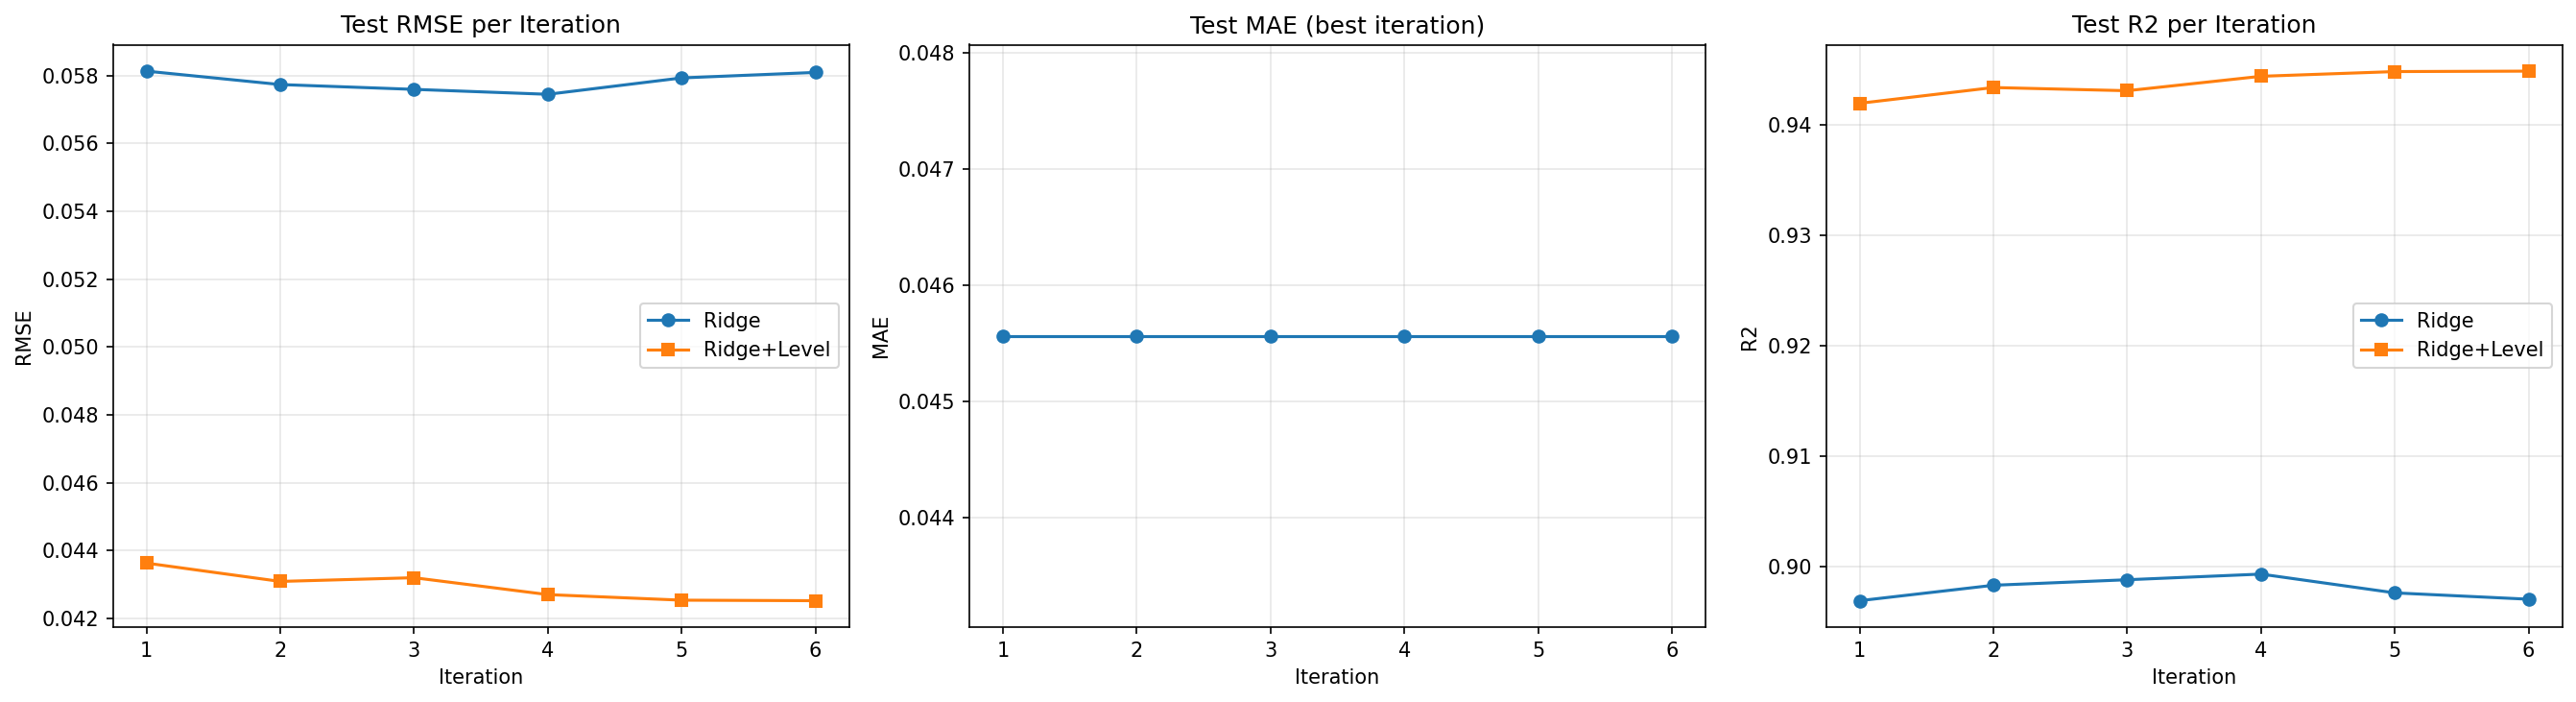


--- prediction_timeseries.png ---


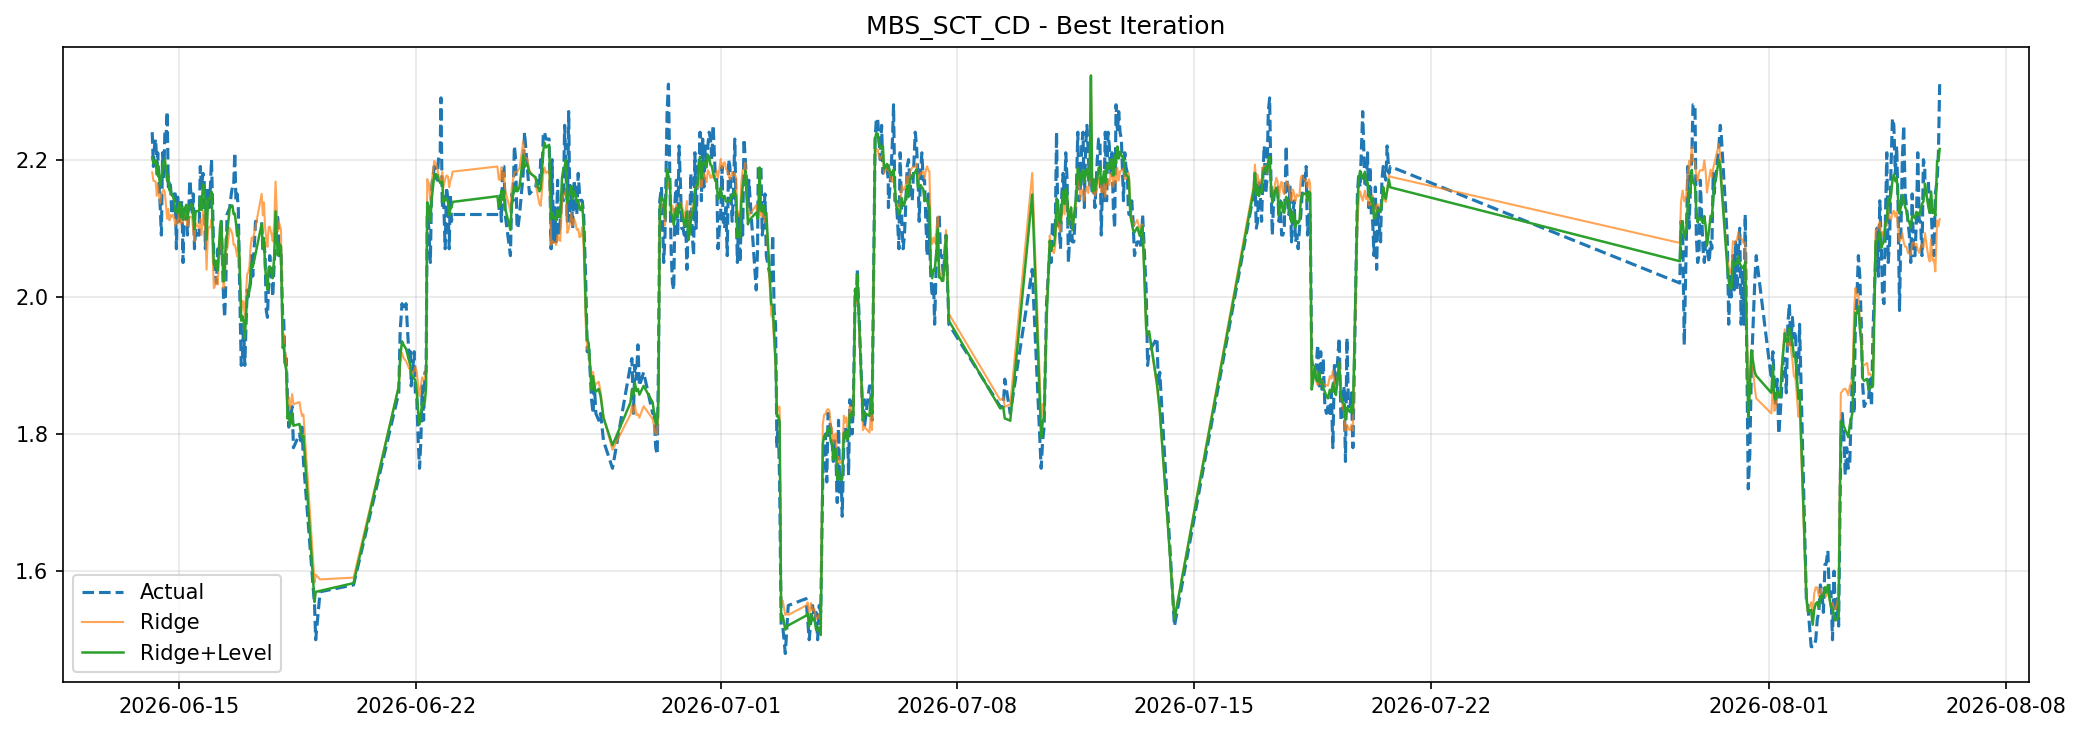


--- local_level.png ---


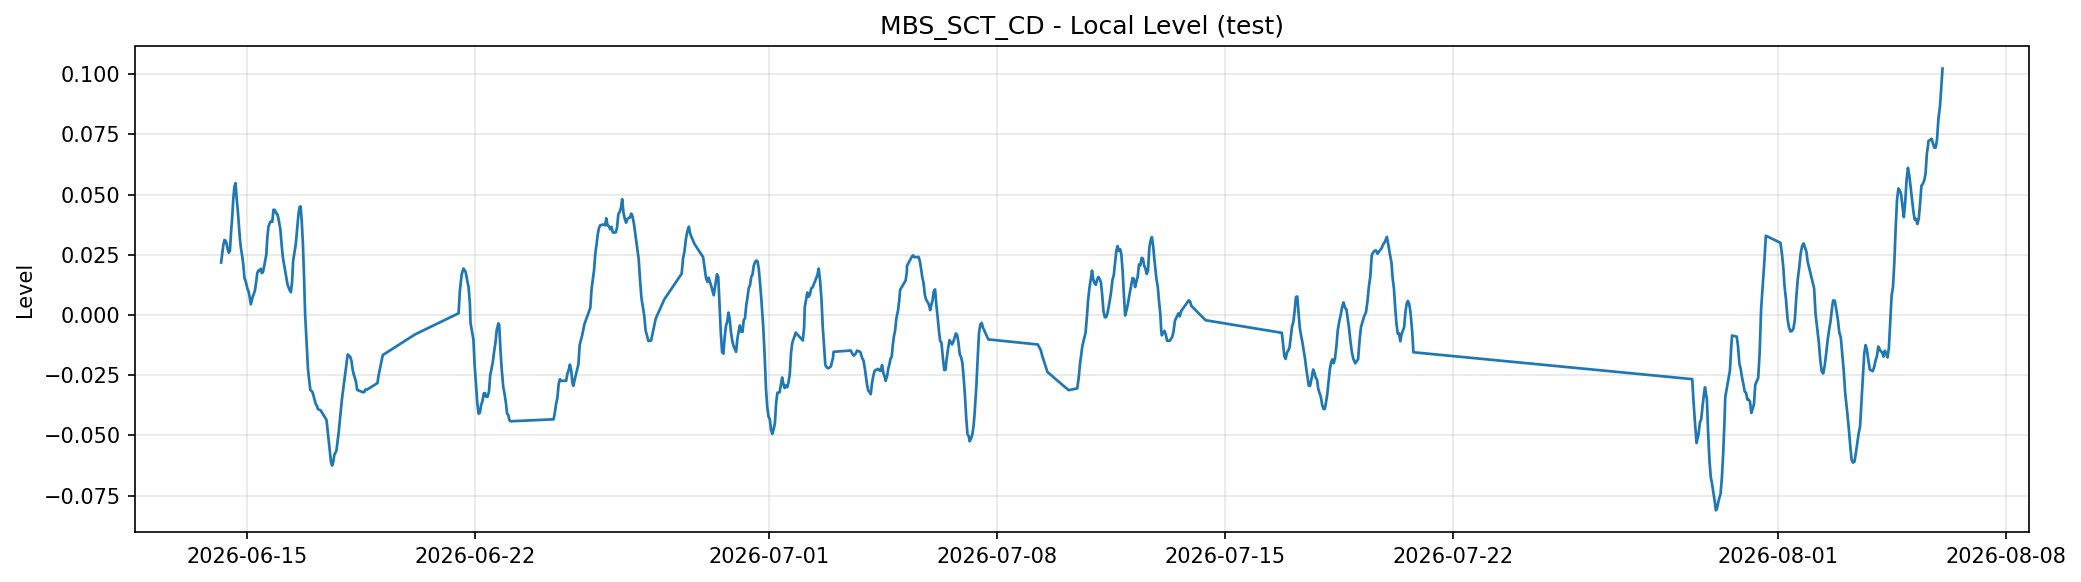


--- scatter.png ---


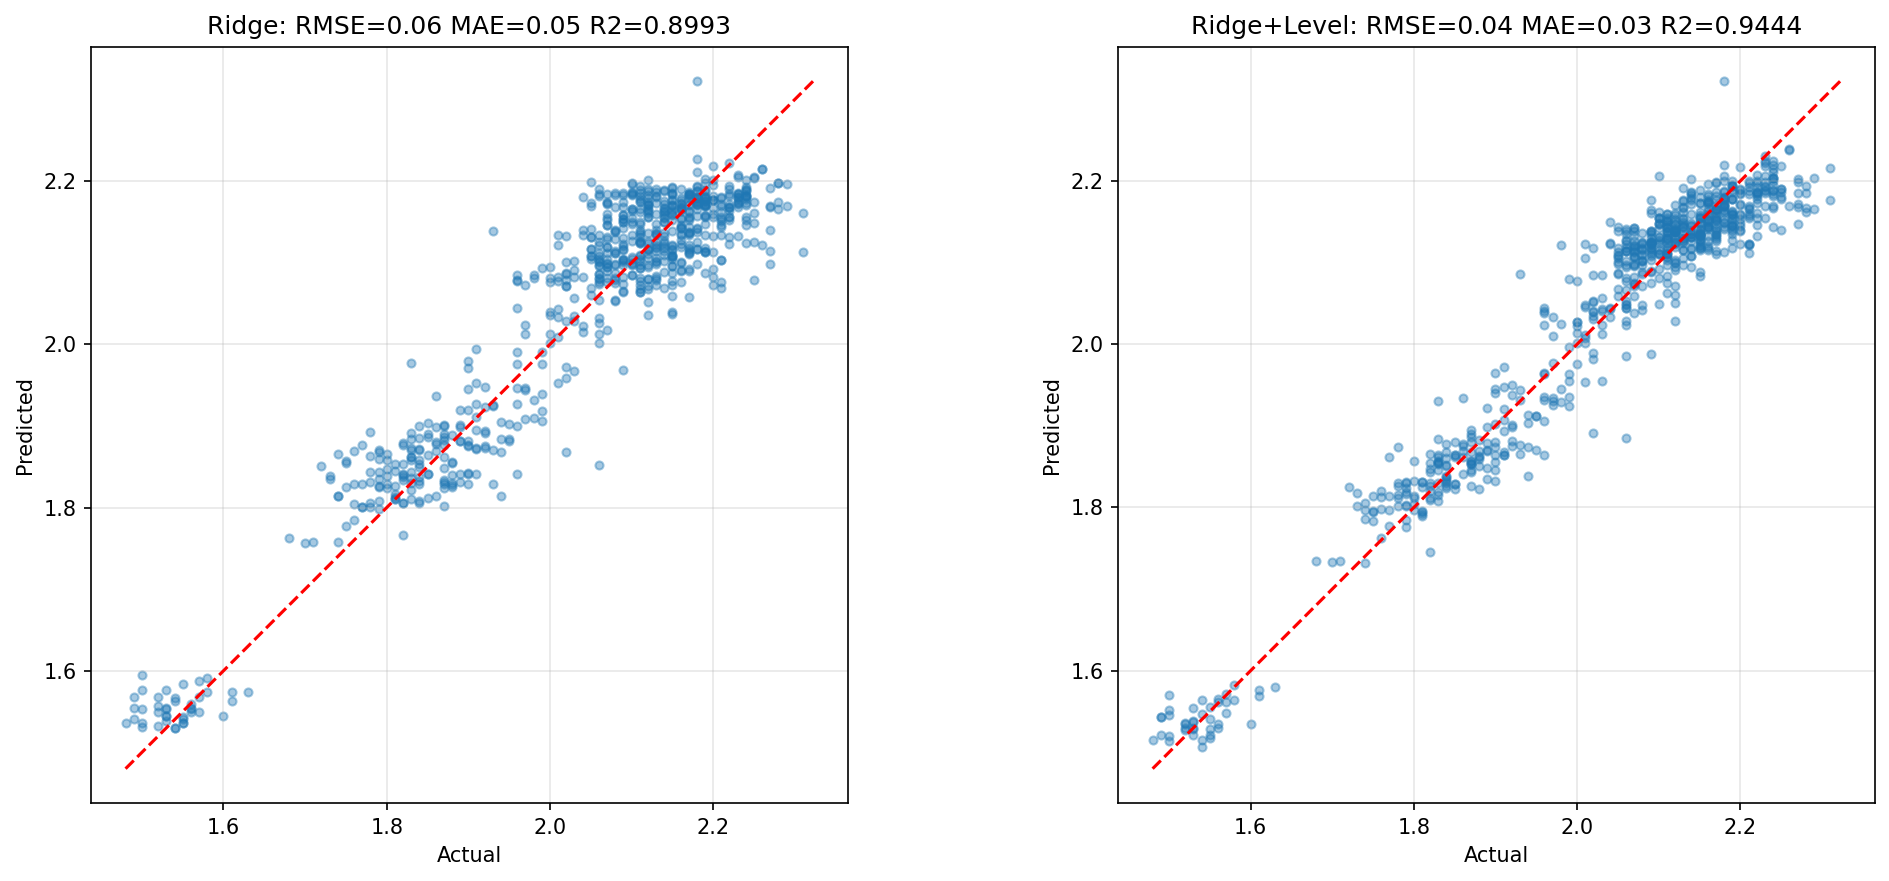

In [33]:
# Display saved plots
from IPython.display import Image, display as ipy_display

for img_name in ["convergence.png", "prediction_timeseries.png", "local_level.png", "scatter.png"]:
    img_path = best_path / img_name
    if img_path.exists():
        print(f"\n--- {img_name} ---")
        ipy_display(Image(filename=str(img_path)))

In [19]:
# Load backfit result for deeper inspection
import cloudpickle

with open(best_path / "backfit_result.pkl", "rb") as f:
    backfit_result = cloudpickle.load(f)

# Iteration history table
hist_df = pd.DataFrame(backfit_result["iteration_history"])
display(hist_df[[
    "iteration", "n_features", "ridge_alpha",
    "rmse_ridge", "rmse_combined", "r2_ridge", "r2_combined",
    "level_scale", "obs_noise_scale",
]])

,iteration,n_features,ridge_alpha,rmse_ridge,rmse_combined,r2_ridge,r2_combined,level_scale,obs_noise_scale
0,1,22,483.293024,18.905056,0.742889,0.609790,0.999397,10.145403,2.475292
1,2,22,1.000000,16.869982,0.742603,0.689278,0.999398,10.333737,2.492637
2,3,22,1.000000,15.962839,0.709605,0.721796,0.999450,10.415315,2.523108
3,4,22,1.000000,16.336979,0.688444,0.708602,0.999483,10.566548,2.469359
4,5,22,1.000000,16.617395,0.582300,0.698513,0.999630,10.470902,2.271433


In [20]:
# Load backfit result for deeper inspection
import sys
from pathlib import Path
import cloudpickle


# Add parent directory (where utility.py lives) to the path
sys.path.insert(0, str(Path.cwd().parent))

from utility import GroupwisePLSTransformer, _feature_engineering, setpoint_df, ewm_reset

with open(best_path / "production_model.pkl", "rb") as f:
    model = cloudpickle.load(f)

X_test = pd.read_parquet(best_path / "X_test.parquet")
X_train = pd.read_parquet(best_path / "X_train.parquet")
y_test = pd.read_parquet(best_path / "y_test.parquet")
y_train = pd.read_parquet(best_path / "y_train.parquet")
turnup_ts = pd.read_parquet(best_path / "turnup_ts.parquet")

In [21]:
from utility import calculate_manual_shap, plotly_shap_beeswarm

base, shap_vals, X_explain, feats = calculate_manual_shap(model['pipeline'], X_reference=turnup_ts.loc[X_train.index,model["feat_list"]], X_sample=turnup_ts.loc[X_test.index,model["feat_list"]], grade_id="6010120", grade_col="AB_Grade_ID")

PermutationExplainer explainer: 204it [02:01,  1.54it/s]                         


In [22]:
fig = plotly_shap_beeswarm(shap_vals, X_explain, feats, max_features=100)
fig.show()

In [25]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set(rc={"figure.figsize": (12, 4)})
sns.set_style("whitegrid")
sns.set_context("notebook")

In [27]:
model["feat_list"]

['Draw_PS-PD1',
 'Draw_WS-PS',
 'Top_wire_tenstion',
 'Bottom_wire_tension',
 'Bottom_Felt_Tension',
 'Dewatering_Suction_Press_Roll',
 'Steam_pressure_for_PM',
 'Stock_deculator_pressure',
 'Inlet_Air_2_Temperature',
 'DG1_Ventilator_Revolution_Output',
 'DG3_Ventilator_Revolution_Output',
 'retention',
 'Retention_Aid_mass_flow__g/T_',
 'Natriumhydroxide_mass_flow__g/T_',
 'Fixative_2_mass_flow__g/T_',
 'grammage',
 'Linepressure_1st_press_FS__bar_',
 'Linepressure_2nd_press_FS__bar_',
 'Linepressure_1st_press_DS__bar_',
 'Linepressure_2nd_press_DS__bar_',
 'Linepressure_shoe_press__bar_',
 'AB_Grade_ID',
 'Starch_uptake_by_paper_Bottom_Roll__g/m2_',
 'Starch_uptake_by_paper_Top_Roll__g/m2_']

<Axes: xlabel='Stock_deculator_pressure', ylabel='Steam__kWh/T_'>

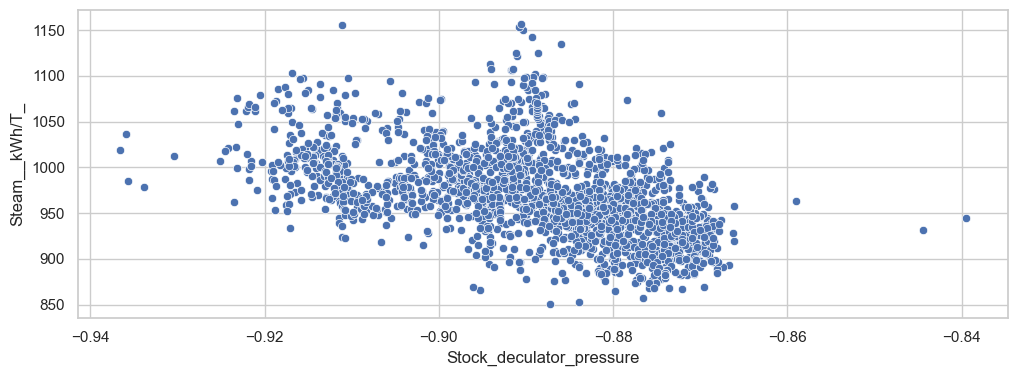

In [30]:
sns.scatterplot(turnup_ts, y="Steam__kWh/T_", x='Stock_deculator_pressure')

<Axes: xlabel='Production_Rate__T/h_', ylabel='Stock_deculator_pressure'>

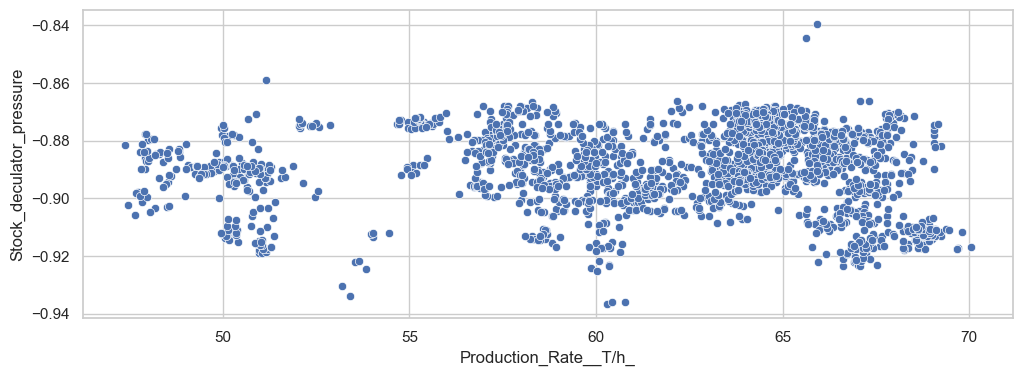

In [28]:
sns.scatterplot(turnup_ts, x= "Production_Rate__T/h_", y='Stock_deculator_pressure')

<Axes: xlabel='Production_Rate__T/h_', ylabel='Steam__kWh/T_'>

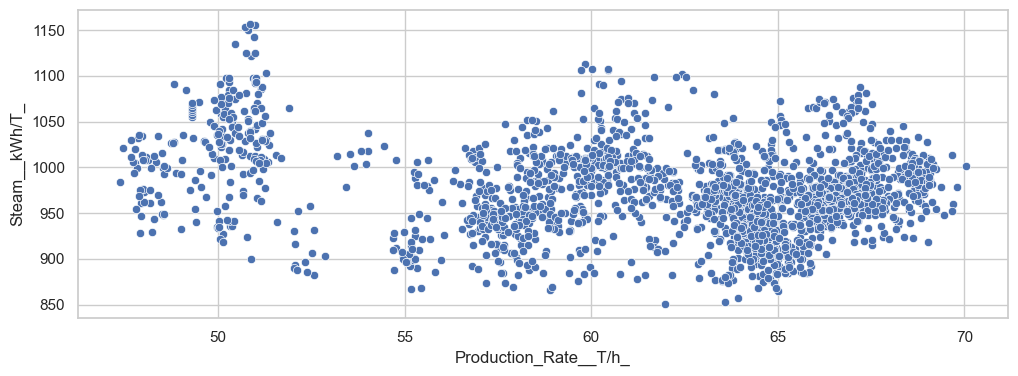

In [26]:
sns.scatterplot(turnup_ts, x= "Production_Rate__T/h_", y="Steam__kWh/T_")